## Section 1 — Setup and Imports

In [1]:
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install torch
# !pip install torchvision

In [ ]:
import os, sys, json
import numpy as np
import torch

PROJECT_PATH = "/Users/manish/Documents/GitHub/Crop-disease-detection"
SRC_PATH = os.path.join(PROJECT_PATH, "src")

# Add project folder to Python path so we can import from pipeline/
if PROJECT_PATH not in sys.path:
    sys.path.insert(0, PROJECT_PATH)
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

# Import our pipeline modules
from config  import CFG as CFG
from data_loader import prepare_data
from model_builder import build_model
from trainer  import train_model
from evaluator import evaluate_model, plot_history

# Create output folders
os.makedirs(CFG["MODELS_DIR"],  exist_ok=True)
os.makedirs(CFG["RESULTS_DIR"], exist_ok=True)

print(f"Device  : {CFG['DEVICE']}")
print(f"Models  : {CFG['MODELS']}")


Device  : mps
Models  : ['MobileNetV2', 'EfficientNetB0', 'ResNet50']


## Section 2 - Baseline (Clean Image)

In [2]:
print(CFG.keys())

dict_keys(['CLEAN_IMAGES', 'CLEAN_LABELS', 'DROP_IMAGES', 'DROP_LABELS', 'MODELS_DIR', 'RESULTS_DIR', 'DEVICE', 'NUM_CLASSES', 'BATCH_SIZE', 'NUM_WORKERS', 'TEST_SIZE', 'VAL_SIZE', 'SEED', 'IMG_MEAN', 'IMG_STD', 'MODELS', 'LR', 'WEIGHT_DECAY', 'EPOCHS', 'PATIENCE', 'SETTINGS', 'MAX_CLASS_WEIGHT'])


In [3]:
# Load the clean dataset
print("Loading clean dataset")

loaders_baseline, test_labels, class_names, encoder = prepare_data(
    CFG["CLEAN_IMAGES"],
    CFG["CLEAN_LABELS"],
    CFG,
)

Loading clean dataset...
  54,305 images  |  38 classes
  Train 34,755  Val 8,689  Test 10,861


In [4]:
print("Train labels:", np.unique(loaders_baseline["train"].dataset.labels))
print("Class names:", class_names)

Train labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37]
Class names: [np.str_('Apple___Apple_scab'), np.str_('Apple___Black_rot'), np.str_('Apple___Cedar_apple_rust'), np.str_('Apple___healthy'), np.str_('Blueberry___healthy'), np.str_('Cherry_(including_sour)___Powdery_mildew'), np.str_('Cherry_(including_sour)___healthy'), np.str_('Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot'), np.str_('Corn_(maize)___Common_rust_'), np.str_('Corn_(maize)___Northern_Leaf_Blight'), np.str_('Corn_(maize)___healthy'), np.str_('Grape___Black_rot'), np.str_('Grape___Esca_(Black_Measles)'), np.str_('Grape___Leaf_blight_(Isariopsis_Leaf_Spot)'), np.str_('Grape___healthy'), np.str_('Orange___Haunglongbing_(Citrus_greening)'), np.str_('Peach___Bacterial_spot'), np.str_('Peach___healthy'), np.str_('Pepper,_bell___Bacterial_spot'), np.str_('Pepper,_bell___healthy'), np.str_('Potato___Early_blight'), np.str_('Potato___Late_blight')


───────────────────────────────────────────────────────
  MobileNetV2
───────────────────────────────────────────────────────
  Total parameters    : 2,272,550

  Training: MobileNetV2  |  baseline

  Class weights  min=0.26  max=3.00  (cap=3.0)

Epoch [ 1/20]  Train Loss: 0.8831  Train Acc: 85.24%  Val Acc: 97.59%  lr=1.00e-04
  ---------------------------------------------------------------------------
Epoch [ 2/20]  Train Loss: 0.0994  Train Acc: 97.72%  Val Acc: 99.14%  lr=1.00e-04
  ---------------------------------------------------------------------------
Epoch [ 3/20]  Train Loss: 0.0545  Train Acc: 98.70%  Val Acc: 99.07%  lr=1.00e-04
  ---------------------------------------------------------------------------
Epoch [ 4/20]  Train Loss: 0.0379  Train Acc: 99.05%  Val Acc: 99.34%  lr=1.00e-04
  ---------------------------------------------------------------------------
Epoch [ 5/20]  Train Loss: 0.0300  Train Acc: 99.36%  Val Acc: 99.33%  lr=1.00e-04
  -----------------------

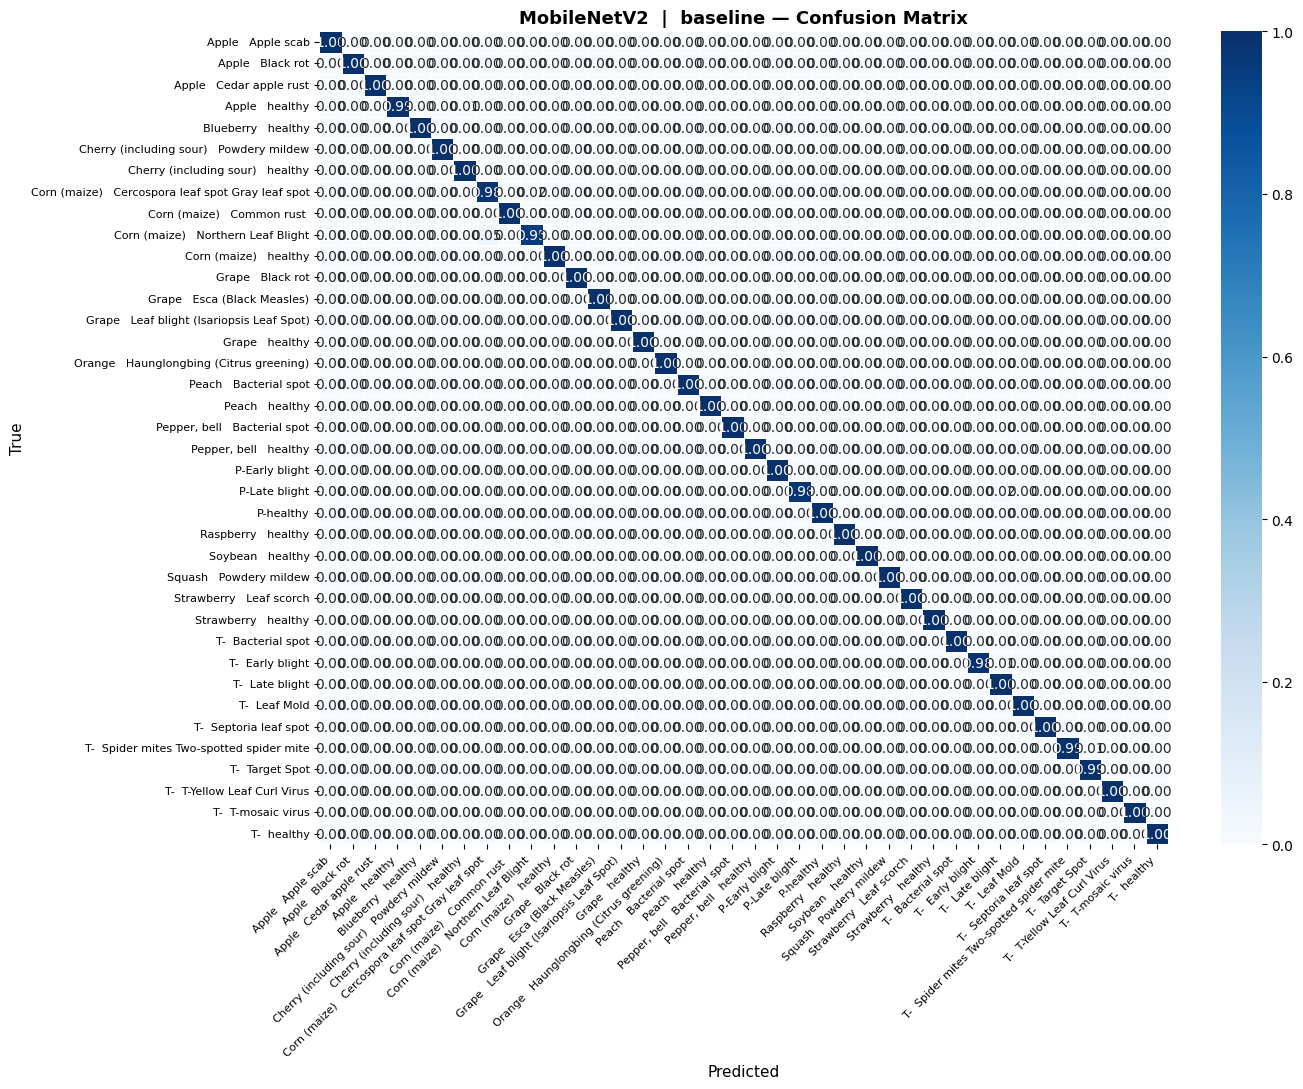

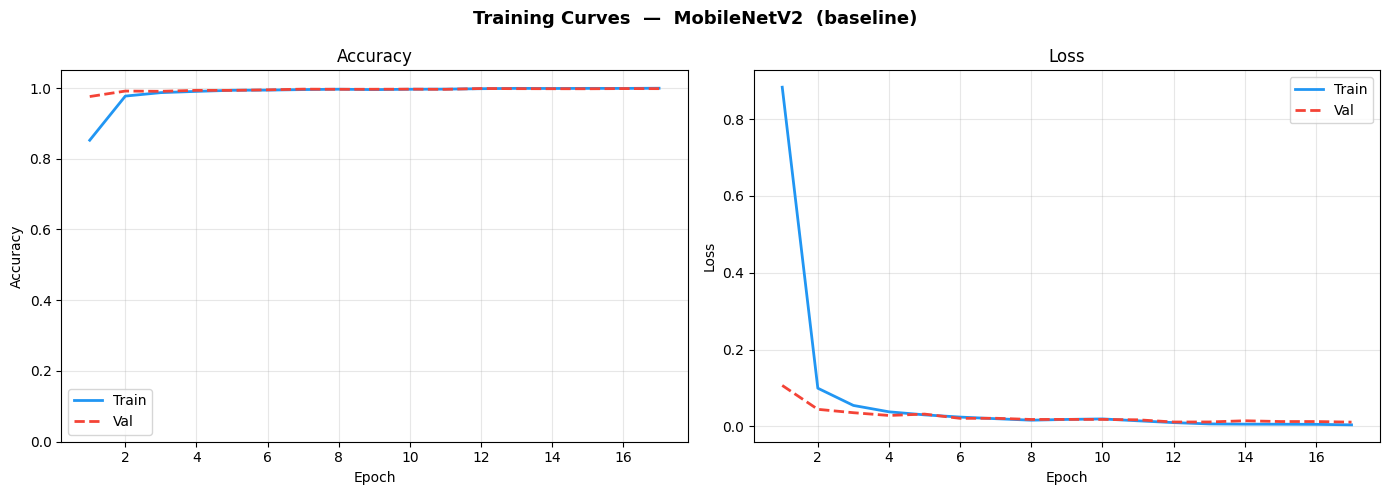


───────────────────────────────────────────────────────
  EfficientNetB0
───────────────────────────────────────────────────────
  Total parameters    : 4,056,226

  Training: EfficientNetB0  |  baseline

  Class weights  min=0.26  max=3.00  (cap=3.0)

Epoch [ 1/20]  Train Loss: 0.7390  Train Acc: 86.72%  Val Acc: 98.35%  lr=1.00e-04
  ---------------------------------------------------------------------------
Epoch [ 2/20]  Train Loss: 0.0780  Train Acc: 98.14%  Val Acc: 99.23%  lr=1.00e-04
  ---------------------------------------------------------------------------
Epoch [ 3/20]  Train Loss: 0.0432  Train Acc: 98.98%  Val Acc: 99.34%  lr=1.00e-04
  ---------------------------------------------------------------------------
Epoch [ 4/20]  Train Loss: 0.0335  Train Acc: 99.06%  Val Acc: 99.54%  lr=1.00e-04
  ---------------------------------------------------------------------------
Epoch [ 5/20]  Train Loss: 0.0259  Train Acc: 99.34%  Val Acc: 99.55%  lr=1.00e-04
  -----------------

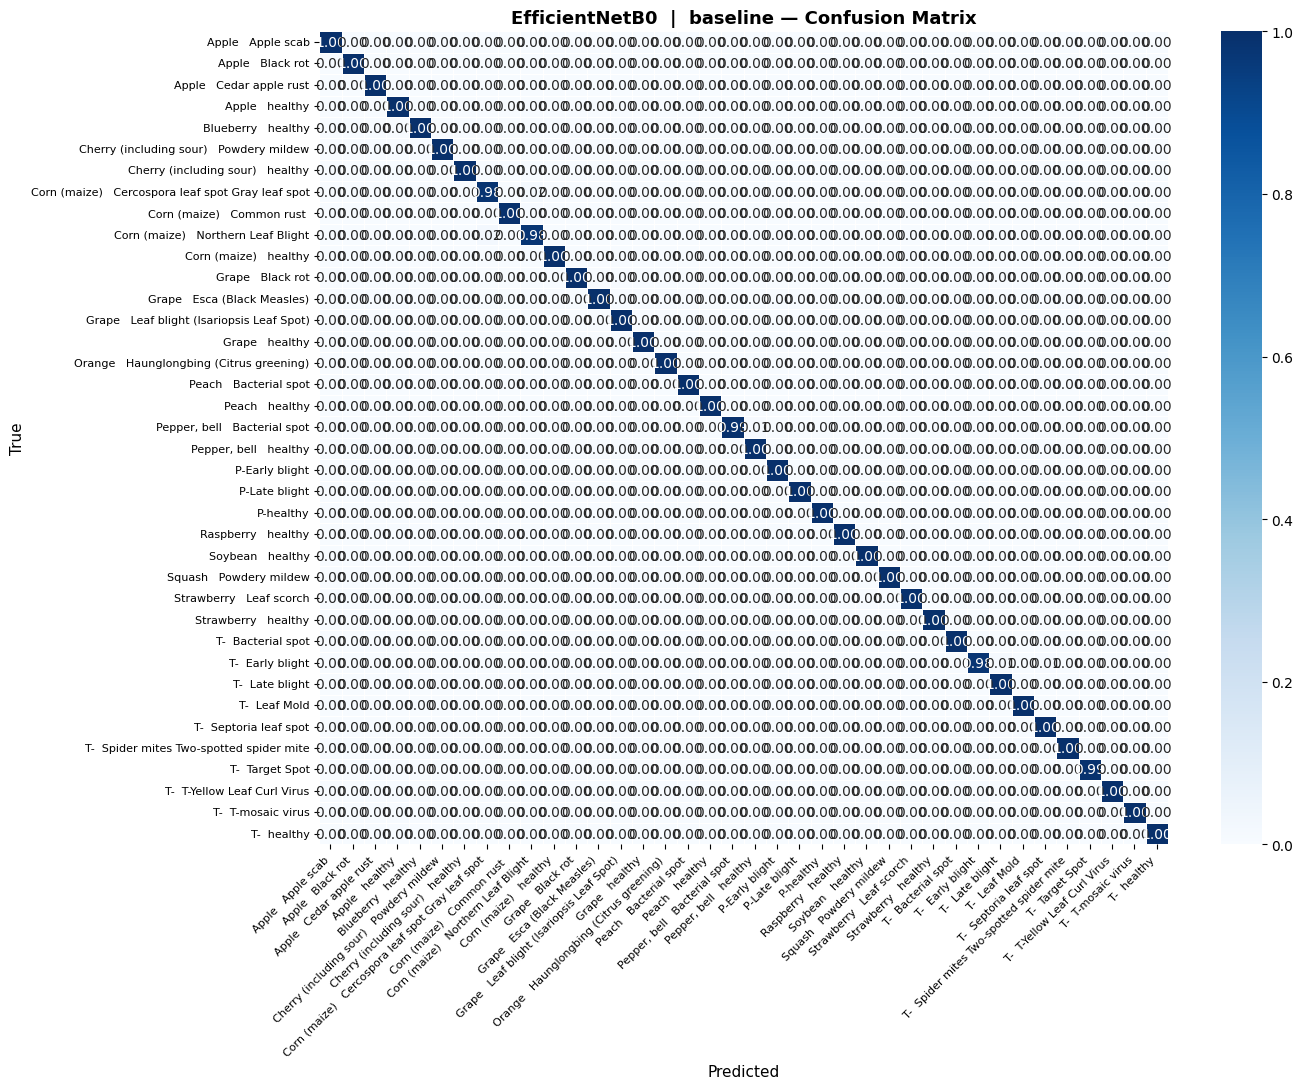

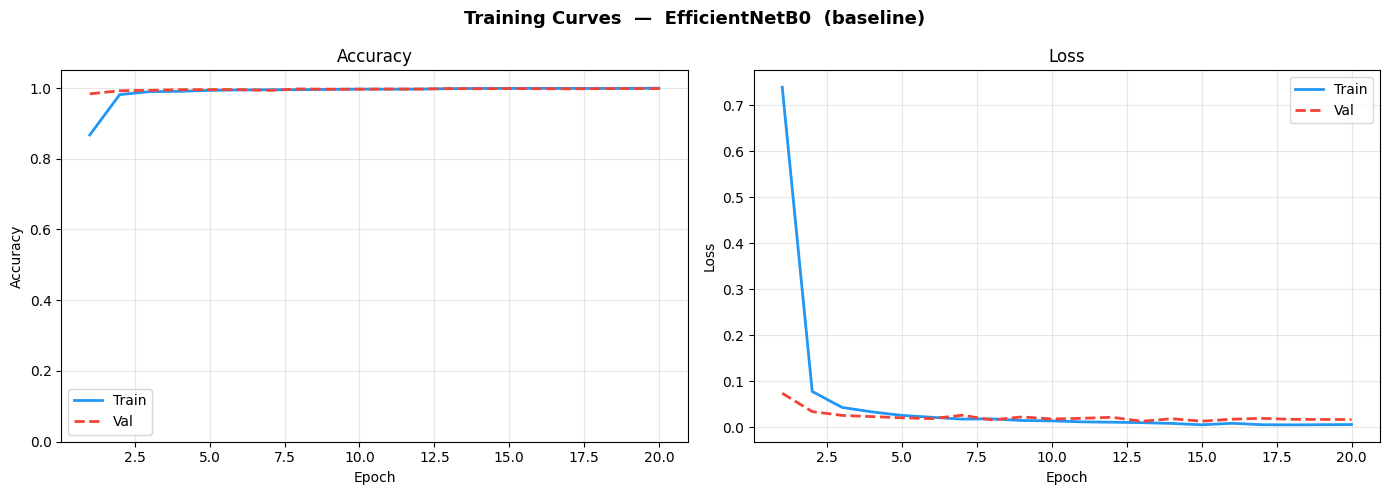


───────────────────────────────────────────────────────
  ResNet50
───────────────────────────────────────────────────────
  Total parameters    : 23,585,894

  Training: ResNet50  |  baseline

  Class weights  min=0.26  max=3.00  (cap=3.0)

Epoch [ 1/20]  Train Loss: 0.4743  Train Acc: 91.12%  Val Acc: 98.19%  lr=1.00e-04
  ---------------------------------------------------------------------------
Epoch [ 2/20]  Train Loss: 0.0534  Train Acc: 98.60%  Val Acc: 99.27%  lr=1.00e-04
  ---------------------------------------------------------------------------
Epoch [ 3/20]  Train Loss: 0.0432  Train Acc: 98.88%  Val Acc: 99.32%  lr=1.00e-04
  ---------------------------------------------------------------------------
Epoch [ 4/20]  Train Loss: 0.0318  Train Acc: 99.18%  Val Acc: 99.34%  lr=1.00e-04
  ---------------------------------------------------------------------------
Epoch [ 5/20]  Train Loss: 0.0251  Train Acc: 99.40%  Val Acc: 99.26%  lr=1.00e-04
  ----------------------------

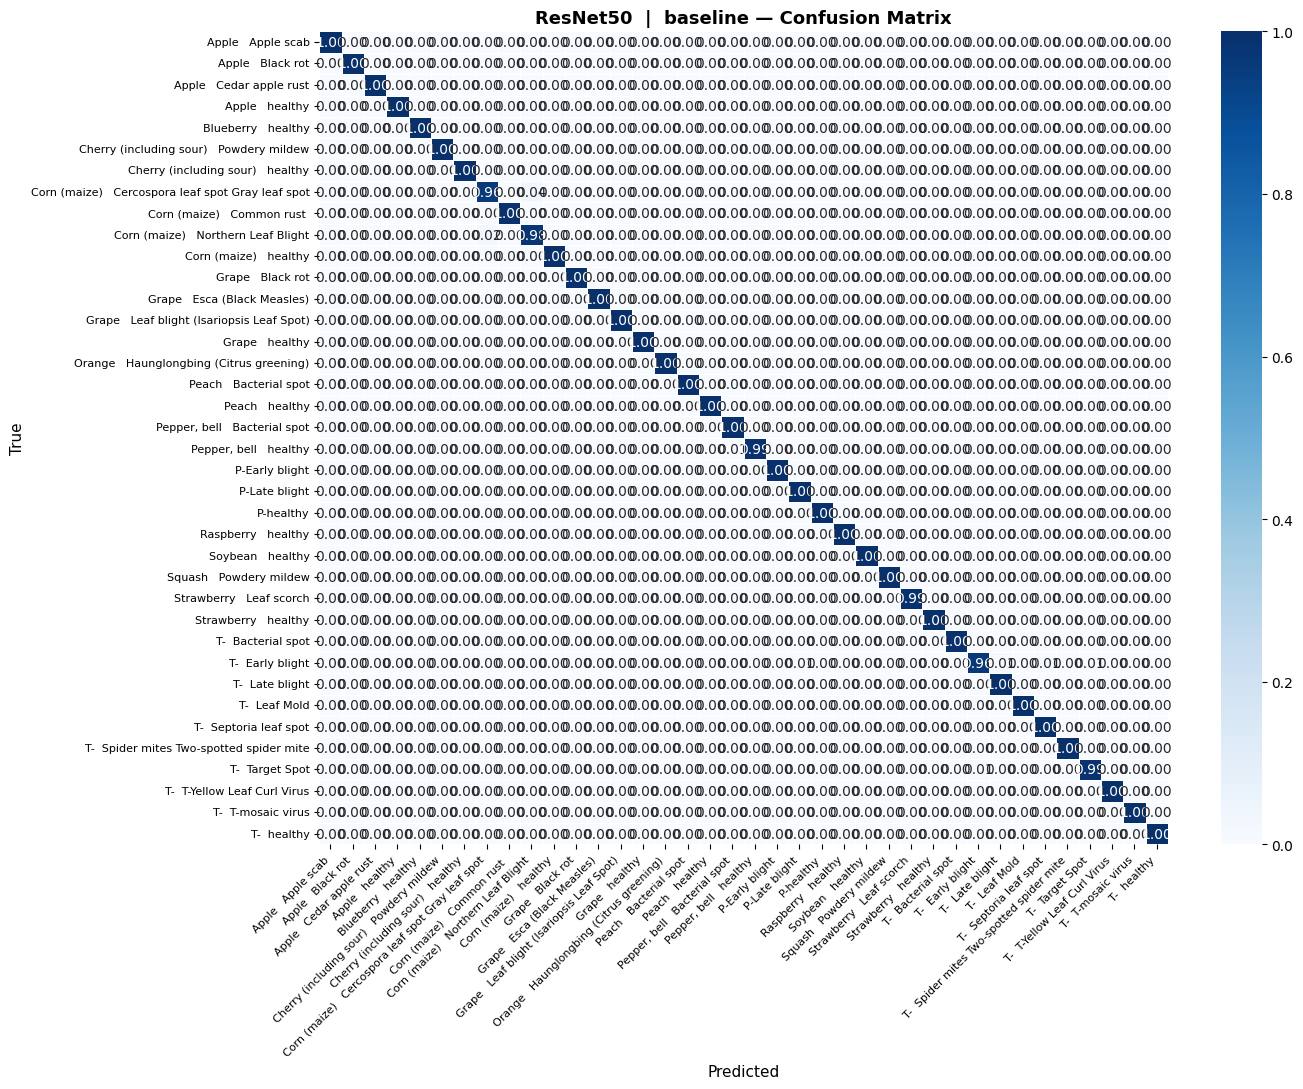

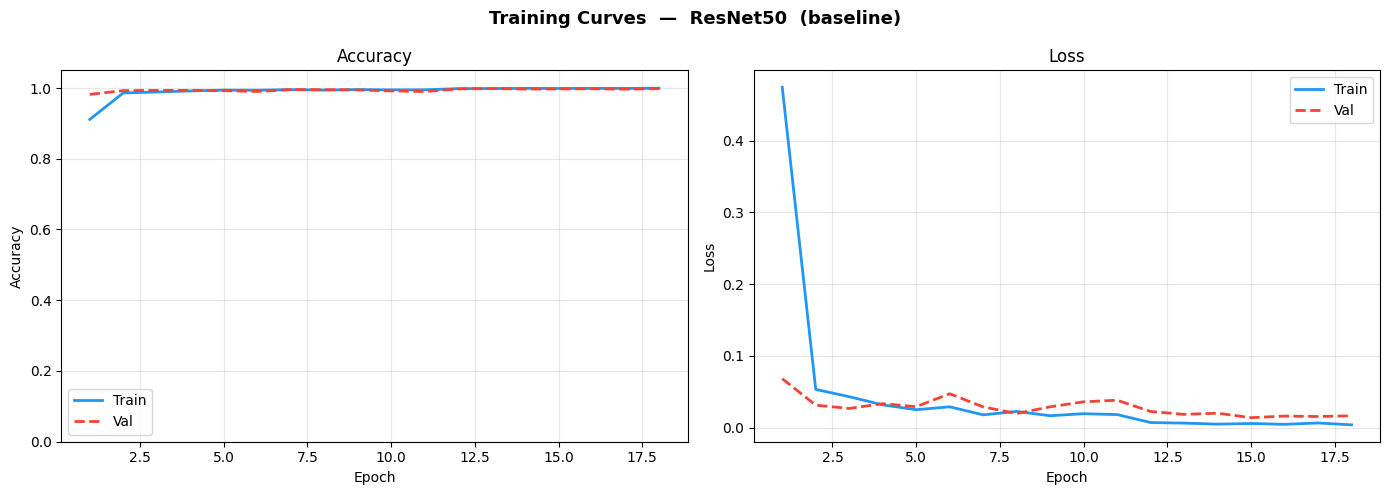

In [5]:
# Train all 3 models — same 4 steps for every model
# build - train - evaluate - plot curves

for model_name in CFG["MODELS"]:

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")

    # Step 1: Build model (load ImageNet weights, freeze base, add our head)
    bundle = build_model(model_name, CFG)

    # Step 2: Train (Phase 1: head only → Phase 2: fine-tune base layers)
    trained_model, history = train_model(bundle, loaders_baseline, "baseline", CFG)

    # Step 3: Test on unseen test images
    evaluate_model(trained_model, loaders_baseline, class_names, model_name, "baseline", CFG)

    # Step 4: Plot accuracy and loss curves
    plot_history(model_name, "baseline", CFG)

    # Free memory before training the next model
    del trained_model, bundle
    torch.mps.empty_cache() if CFG["DEVICE"] == "mps" else None
